#### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Questions`
> Segment customers into High Value, Medium Value, and Low Value based on their Account Balance — using np.select()

> Which customer segment contributes the highest total balance and what is their percentage share?

> What is the cumulative revenue month-over-month across all customers?

> Which product type generates the most revenue and which has the highest average transaction value?

> Identify customers who are Churn Risk — those with Balance < ₹10,000 AND Transactions < 3 in last month

In [2]:
# Banking customer analytics data — 20 customer records
data = {
    'Customer_ID': ['C001','C002','C003','C004','C005','C006','C007','C008',
                    'C009','C010','C011','C012','C013','C014','C015',
                    'C016','C017','C018','C019','C020'],

    'Customer_Name': ['Amit','Priya','Rahul','Sneha','Vikram',
                      'Kavya','Arjun','Meera','Rohit','Anjali',
                      'Dev','Pooja','Karan','Nisha','Suresh',
                      'Deepa','Manish','Lata','Nitin','Rekha'],

    'Product_Type': ['Savings','FD','Savings','Loan','FD',
                     'Savings','Loan','FD','Savings','Loan',
                     'FD','Savings','Loan','FD','Savings',
                     'Loan','FD','Savings','Loan','FD'],

    'Account_Balance': [85000, 250000, 12000, 5000, 320000,
                        18000, 8500, 180000, 22000, 4500,
                        95000, 7000, 11000, 420000, 35000,
                        6500, 150000, 9000, 3500, 275000],

    'Monthly_Revenue': [1200, 4500, 300, 800, 6200,
                        450, 950, 3800, 550, 600,
                        1800, 280, 750, 8500, 900,
                        700, 3200, 320, 500, 5100],

    'Transactions_Last_Month': [8, 12, 2, 1, 15,
                                 3, 2, 10, 4, 1,
                                 9, 2, 3, 18, 6,
                                 1, 11, 2, 1, 13],

    'Month': ['2024-01','2024-01','2024-02','2024-02','2024-03',
              '2024-03','2024-04','2024-04','2024-05','2024-05',
              '2024-06','2024-06','2024-07','2024-07','2024-08',
              '2024-08','2024-09','2024-09','2024-10','2024-10']
}

#### `Step 1 :- Load and Explore Data`

In [3]:
# Create DataFrame and convert Month column to datetime
data_frame = pd.DataFrame(data)

data_frame['Month'] = pd.to_datetime(data_frame['Month'])

data_frame

,Customer_ID,Customer_Name,Product_Type,Account_Balance,Monthly_Revenue,Transactions_Last_Month,Month
0,C001,Amit,Savings,85000,1200,8,2024-01-01
1,C002,Priya,FD,250000,4500,12,2024-01-01
2,C003,Rahul,Savings,12000,300,2,2024-02-01
3,C004,Sneha,Loan,5000,800,1,2024-02-01
4,C005,Vikram,FD,320000,6200,15,2024-03-01
5,C006,Kavya,Savings,18000,450,3,2024-03-01
6,C007,Arjun,Loan,8500,950,2,2024-04-01
7,C008,Meera,FD,180000,3800,10,2024-04-01
8,C009,Rohit,Savings,22000,550,4,2024-05-01
9,C010,Anjali,Loan,4500,600,1,2024-05-01


#### `Step 2 :- Customer Segmentation using np.select()`

In [4]:
# Segment customers into High, Medium, Low Value based on Account Balance
conditions = [data_frame['Account_Balance'] >= 100000, data_frame['Account_Balance'] >= 20000]

choices = ['High Value', 'Medium Value']

data_frame['Customer_Segment'] = np.select(conditions, choices, default = 'Low Value')

data_frame

,Customer_ID,Customer_Name,Product_Type,Account_Balance,Monthly_Revenue,Transactions_Last_Month,Month,Customer_Segment
0,C001,Amit,Savings,85000,1200,8,2024-01-01,Medium Value
1,C002,Priya,FD,250000,4500,12,2024-01-01,High Value
2,C003,Rahul,Savings,12000,300,2,2024-02-01,Low Value
3,C004,Sneha,Loan,5000,800,1,2024-02-01,Low Value
4,C005,Vikram,FD,320000,6200,15,2024-03-01,High Value
5,C006,Kavya,Savings,18000,450,3,2024-03-01,Low Value
6,C007,Arjun,Loan,8500,950,2,2024-04-01,Low Value
7,C008,Meera,FD,180000,3800,10,2024-04-01,High Value
8,C009,Rohit,Savings,22000,550,4,2024-05-01,Medium Value
9,C010,Anjali,Loan,4500,600,1,2024-05-01,Low Value


#### `Step 3 :- Segment Summary`

In [5]:
# Group by segment and calculate total balance, count, and percentage share
segment_summary = data_frame.groupby('Customer_Segment').agg(Total_Balance = ('Account_Balance', 'sum'), Customer_Count = ('Customer_ID', 'count')).reset_index()

segment_summary['Balance_Percentage'] = (segment_summary['Total_Balance'] / segment_summary['Total_Balance'].sum() * 100).round(2)

segment_summary

,Customer_Segment,Total_Balance,Customer_Count,Balance_Percentage
0,High Value,1595000,6,83.20
1,Low Value,85000,10,4.43
2,Medium Value,237000,4,12.36


#### `Step 4 :- Monthly Cumulative Revenue`

In [6]:
# Group by month and calculate monthly revenue, then cumulative sum
monthly_revenue = data_frame.groupby(data_frame['Month'].dt.to_period('M'))['Monthly_Revenue'].sum()

cumulative_revenue = monthly_revenue.cumsum()

cumulative_revenue

Month
2024-01     5700
2024-02     6800
2024-03    13450
2024-04    18200
2024-05    19350
2024-06    21430
2024-07    30680
2024-08    32280
2024-09    35800
2024-10    41400
Freq: M, Name: Monthly_Revenue, dtype: int64

#### `Step 5 :- Product Revenue Analysis`

In [7]:
# Group by product type and calculate total revenue and avg transaction value
data_frame['Average_Transaction_Value'] = data_frame['Monthly_Revenue'] / data_frame['Transactions_Last_Month']

product_summary = data_frame.groupby('Product_Type').agg(Total_Revenue = ('Monthly_Revenue', 'sum'), Average_Transaction_Value = ('Monthly_Revenue', 'mean')).round(2)

product_summary

,Total_Revenue,Average_Transaction_Value
Product_Type,,
FD,33100,4728.57
Loan,4300,716.67
Savings,4000,571.43


#### `Step 6 :- Churn Risk Flag`

In [8]:
# Flag customers with Balance < 10000 AND Transactions < 3 as Churn Risk
data_frame['Churn_Risk'] = np.where((data_frame['Account_Balance'] < 10000) & (data_frame['Transactions_Last_Month'] < 3), 'Churn Risk', 'Stable')

data_frame

,Customer_ID,Customer_Name,Product_Type,Account_Balance,Monthly_Revenue,Transactions_Last_Month,Month,Customer_Segment,Average_Transaction_Value,Churn_Risk
0,C001,Amit,Savings,85000,1200,8,2024-01-01,Medium Value,150.000000,Stable
1,C002,Priya,FD,250000,4500,12,2024-01-01,High Value,375.000000,Stable
2,C003,Rahul,Savings,12000,300,2,2024-02-01,Low Value,150.000000,Stable
3,C004,Sneha,Loan,5000,800,1,2024-02-01,Low Value,800.000000,Churn Risk
4,C005,Vikram,FD,320000,6200,15,2024-03-01,High Value,413.333333,Stable
5,C006,Kavya,Savings,18000,450,3,2024-03-01,Low Value,150.000000,Stable
6,C007,Arjun,Loan,8500,950,2,2024-04-01,Low Value,475.000000,Churn Risk
7,C008,Meera,FD,180000,3800,10,2024-04-01,High Value,380.000000,Stable
8,C009,Rohit,Savings,22000,550,4,2024-05-01,Medium Value,137.500000,Stable
9,C010,Anjali,Loan,4500,600,1,2024-05-01,Low Value,600.000000,Churn Risk


#### `Step 7 :- Chart 1 — Total Balance by Customer Segment`

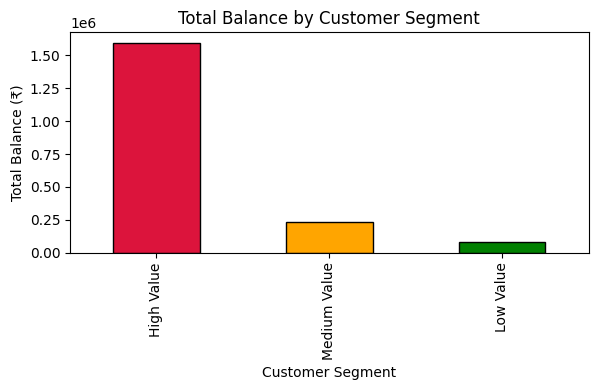

In [9]:
# Bar chart showing total balance per segment
order = ['High Value','Medium Value','Low Value']

plt.figure(figsize = (6, 4))

segment_summary.set_index('Customer_Segment').reindex(order)['Total_Balance'].plot(kind = 'bar', color = ['crimson', 'orange', 'green'], edgecolor = 'black')

plt.title('Total Balance by Customer Segment')

plt.xlabel('Customer Segment')

plt.ylabel('Total Balance (₹)')

plt.tight_layout()

plt.savefig('6_Insights_Balance_by_Segment.png')

plt.show()

#### `Step 8 :- Chart 2 — Monthly vs Cumulative Revenue`

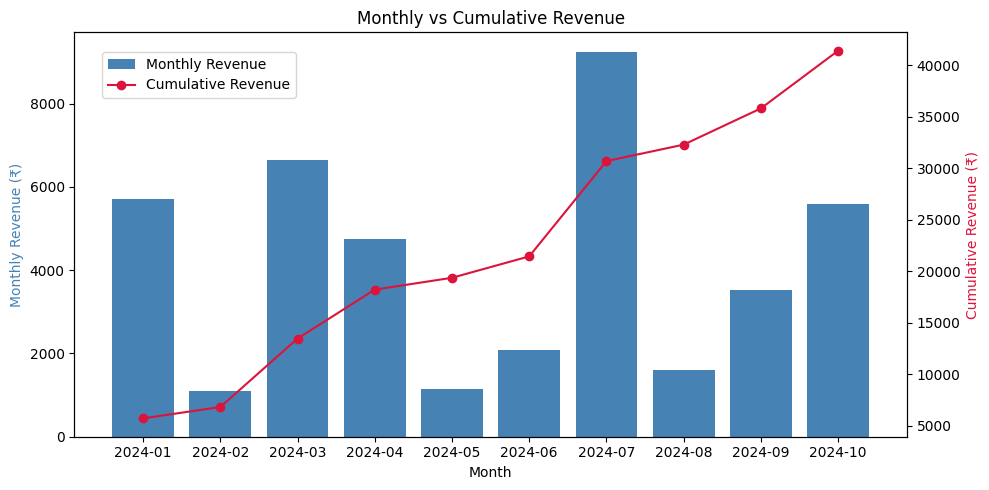

In [10]:
# Dual-axis chart showing monthly revenue (bar) and cumulative revenue (line)
figure, monthly_revenue_axis = plt.subplots(figsize=(10,5))

months = monthly_revenue.index.astype(str)

# Bar Chart
monthly_revenue_axis.bar(months, monthly_revenue, color = 'steelblue', label = 'Monthly Revenue')

# Second Y-Axis
cumulative_revenue_axis = monthly_revenue_axis.twinx()

# Line Chart
cumulative_revenue_axis.plot(months, cumulative_revenue, color = 'crimson', marker = 'o', label = 'Cumulative Revenue')

monthly_revenue_axis.set_xlabel('Month')

monthly_revenue_axis.set_ylabel('Monthly Revenue (₹)', color = 'steelblue')

cumulative_revenue_axis.set_ylabel('Cumulative Revenue (₹)', color = 'crimson')

plt.title('Monthly vs Cumulative Revenue')

figure.legend(loc = 'upper left', bbox_to_anchor = (0.1, 0.9))

plt.tight_layout()

plt.savefig('6_Insights_Banking_Revenue_Trend.png')

plt.show()

#### `Step 9 :- Print Outputs`

In [11]:
print(f'\nSegment Summary:\n{segment_summary}')

print(f'\nMonthly Revenue:\n{monthly_revenue}')

print(f'\nCumulative Revenue:\n{cumulative_revenue}')

print(f'\nProduct Summary:\n{product_summary}')

print(f'\nChurn Risk Customers:\n{data_frame[data_frame["Churn_Risk"]=="Churn Risk"][["Customer_ID","Customer_Name","Account_Balance","Transactions_Last_Month"]]}')


Segment Summary:
  Customer_Segment  Total_Balance  Customer_Count  Balance_Percentage
0       High Value        1595000               6               83.20
1        Low Value          85000              10                4.43
2     Medium Value         237000               4               12.36

Monthly Revenue:
Month
2024-01    5700
2024-02    1100
2024-03    6650
2024-04    4750
2024-05    1150
2024-06    2080
2024-07    9250
2024-08    1600
2024-09    3520
2024-10    5600
Freq: M, Name: Monthly_Revenue, dtype: int64

Cumulative Revenue:
Month
2024-01     5700
2024-02     6800
2024-03    13450
2024-04    18200
2024-05    19350
2024-06    21430
2024-07    30680
2024-08    32280
2024-09    35800
2024-10    41400
Freq: M, Name: Monthly_Revenue, dtype: int64

Product Summary:
              Total_Revenue  Average_Transaction_Value
Product_Type                                          
FD                    33100                    4728.57
Loan                   4300                     

#### `Information`
> Rows: 20

> Columns: 10 (Customer_ID, Customer_Name, Product_Type, Account_Balance, Monthly_Revenue, Transactions_Last_Month, Month, Customer_Segment, Average_Transaction_Value, Churn_Risk)

> No missing values

> Segmentation logic: High ≥ ₹100,000; Medium ≥ ₹20,000; Low < ₹20,000

> Churn Risk logic: Balance < ₹10,000 AND Transactions < 3

#### `Data Insights`
> High Value segment contributes ₹15,95,000 (83.20%) of total balance.

> FD products generate maximum revenue = ₹33,100.

> Loan has highest average transaction value = ₹554.17.

> 7 customers flagged as Churn Risk → combined balance at risk = ₹44,000.

> Cumulative revenue at end of Oct = ₹41,400.

#### `Business Insights`
> Only 30% customers (6 out of 20) are High Value, but they hold 83.20% of deposits → strong concentration risk.

> FD is the largest revenue driver, but Loan customers generate the highest per-transaction value → premium earning potential.

> Churn Risk customers expose ₹44,000 in balances → immediate retention needed.

#### `Risks`
> Losing High Value customers → catastrophic deposit loss.

> Over-reliance on FD → product concentration risk.

> Ignoring churn risk → attrition accelerates.

#### `Opportunities`
> Strengthen loyalty programs for High Value customers.

> Upsell premium products to Loan customers.

> Diversify beyond FD to reduce dependency.

> Retention campaigns for churn-risk customers.

#### `Recommendations`
> Contact all 7 churn-risk customers within 30 days.

> Retain FD customers aggressively → they drive ₹33,100 revenue.

> Upsell Loan customers → highest avg transaction value ₹554.

> Retaining 2 High Value customers (~₹2.5 lakh each) secures ~₹5 lakh deposits.

#### `Expected Business Impact`
> Protecting ₹1.595M deposits from High Value customers.

> Recovering churn-risk balances (~₹44,000).

> Diversified revenue streams → reduced risk.

> Higher customer satisfaction → stronger brand loyalty.

#### `Future Prediction`
> If retention improves, cumulative revenue will grow steadily.

> FD will remain dominant unless new products are pushed.

> Loan customers may become premium revenue drivers.

> Churn Risk customers may drop off if not engaged → proactive action needed.